# Bank Churn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
import math
from sklearn.metrics import f1_score
from sklearn.preprocessing import MinMaxScaler , LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

In [4]:
df = pd.read_csv(r"C:\Users\G16\Downloads\archive\train.csv")

In [5]:
df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165029,165029,15667085,Meng,667,Spain,Female,33.0,2,0.00,1,1.0,1.0,131834.75,0
165030,165030,15665521,Okechukwu,792,France,Male,35.0,3,0.00,1,0.0,0.0,131834.45,0
165031,165031,15664752,Hsia,565,France,Male,31.0,5,0.00,1,1.0,1.0,127429.56,0
165032,165032,15689614,Hsiung,554,Spain,Female,30.0,7,161533.00,1,0.0,1.0,71173.03,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  object 
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  object 
 5   Gender           165034 non-null  object 
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 17.6+ MB


In [7]:
df.isna().sum()

id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

##  NO NULL FOUND 

## Columns [  Surname   ,       Geography    ,     Gender    ] are object type

In [8]:
df.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,165034.0000,1.650340e+05,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
mean,82516.5000,1.569201e+07,656.454373,38.125888,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,47641.3565,7.139782e+04,80.103340,8.867205,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,0.0000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,41258.2500,1.563314e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,82516.5000,1.569017e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,123774.7500,1.575682e+07,710.000000,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000
max,165033.0000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [9]:
df2 = df[["id" , "CustomerId" , "Exited"]]

In [10]:
correlation_matrix = df2.corr()

<Axes: >

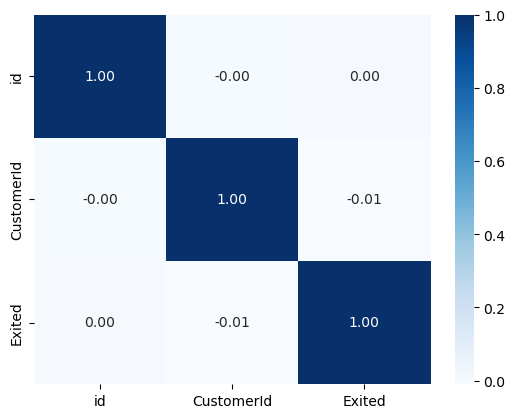

In [11]:
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f')

<Axes: >

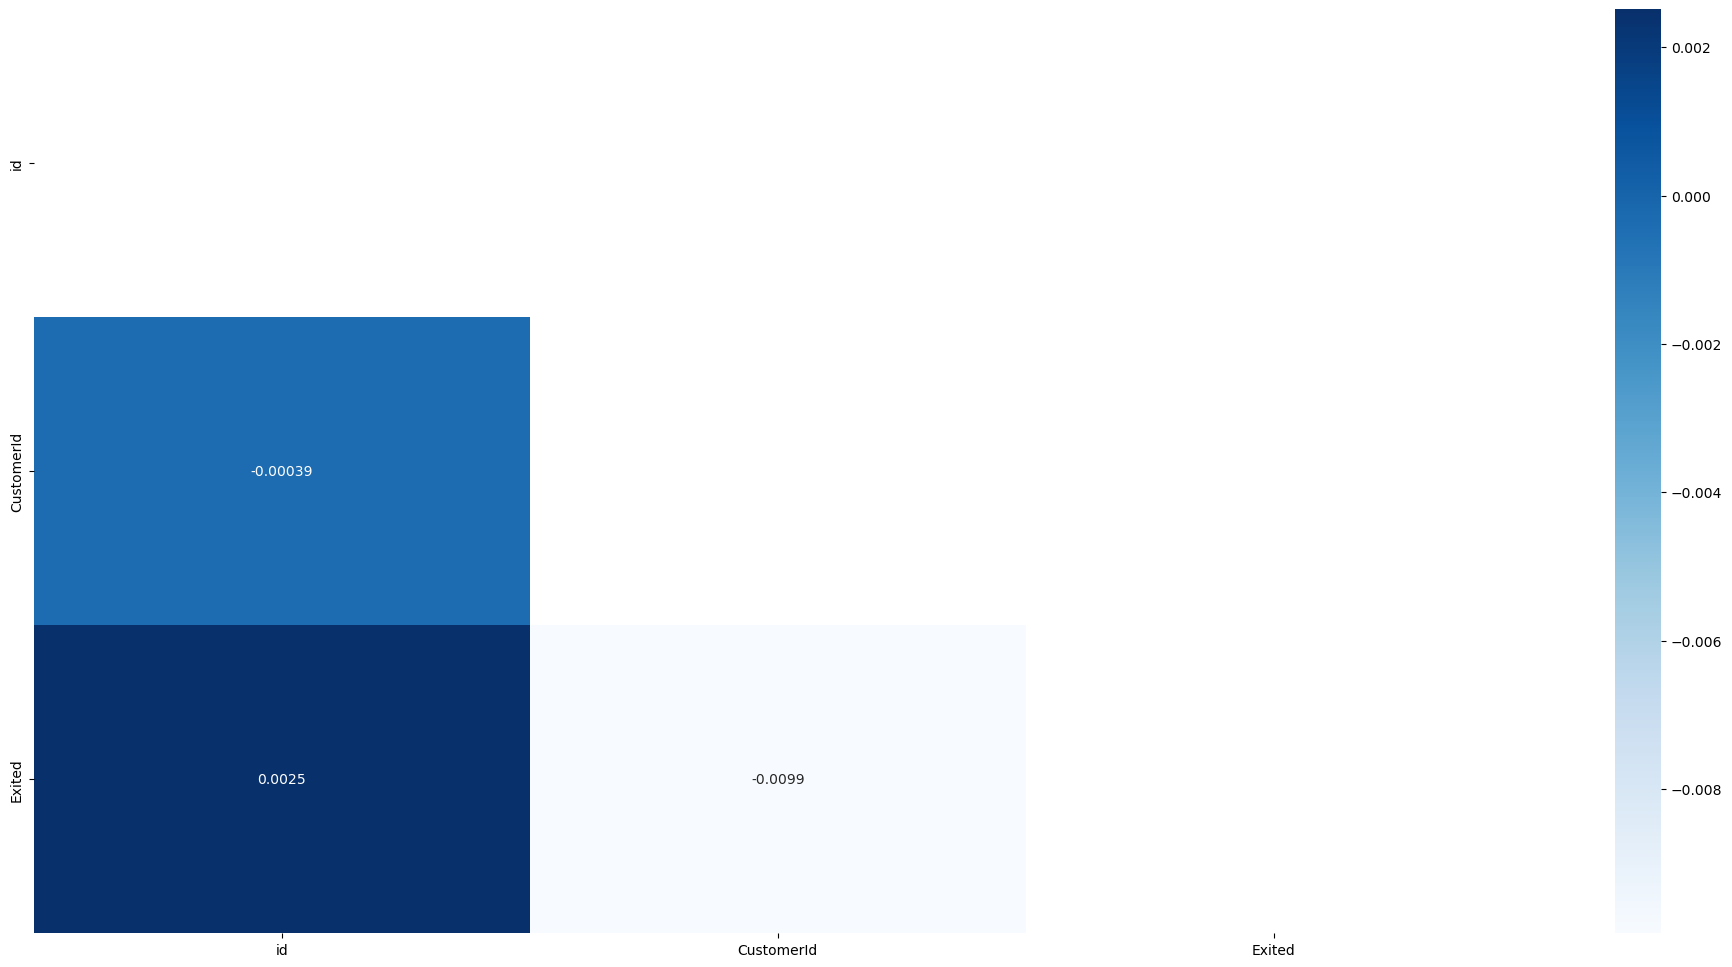

In [12]:
plt.figure(figsize=(24,12))
sns.heatmap(correlation_matrix,annot=True,cmap="Blues",mask=np.triu(np.ones_like(correlation_matrix, dtype=bool)))

### [Surname , id , CustomerId] is not affecting to target so drop them

In [13]:
df.drop(columns=["Surname" , "id" , "CustomerId" ] , inplace=True)

In [14]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0
...,...,...,...,...,...,...,...,...,...,...,...
165029,667,Spain,Female,33.0,2,0.00,1,1.0,1.0,131834.75,0
165030,792,France,Male,35.0,3,0.00,1,0.0,0.0,131834.45,0
165031,565,France,Male,31.0,5,0.00,1,1.0,1.0,127429.56,0
165032,554,Spain,Female,30.0,7,161533.00,1,0.0,1.0,71173.03,0


<Axes: xlabel='Geography', ylabel='count'>

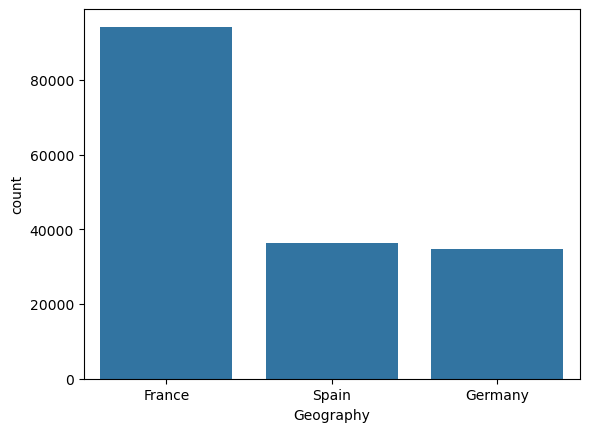

In [15]:
sns.countplot(data=df , x="Geography")

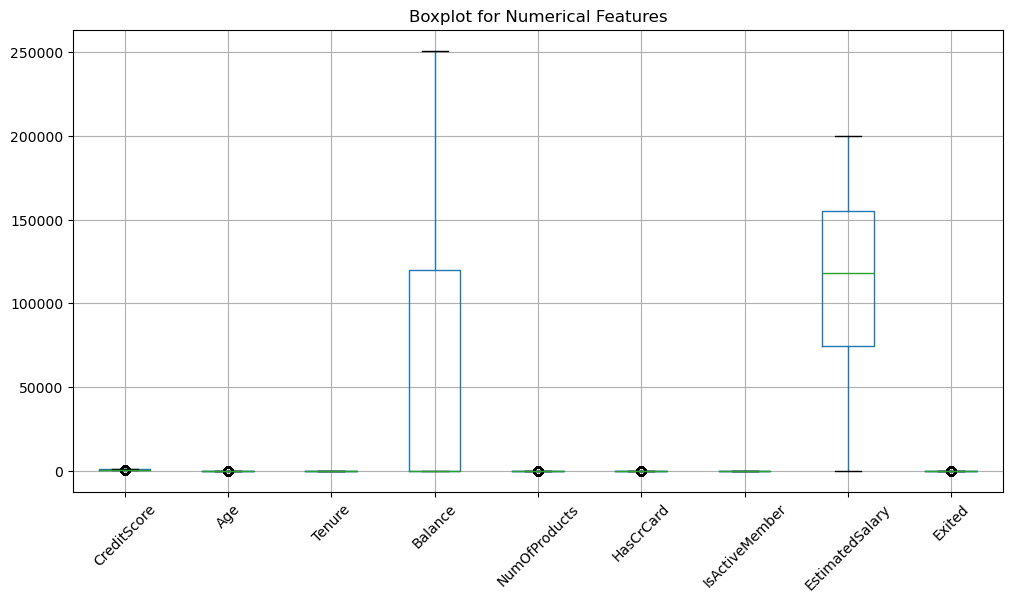

In [16]:
df.boxplot(figsize=(12,6), rot=45)
plt.title("Boxplot for Numerical Features")
plt.show()

# Encoding Object Columns

In [17]:
# df  = pd.get_dummies(df , columns=["Gender" , "Geography"] , drop_first=True , dtype=int )

In [18]:
df = pd.get_dummies(df, columns=['Geography'], drop_first=True, dtype=int)
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,668,1,33.0,3,0.00,2,1.0,0.0,181449.97,0,0,0
1,627,1,33.0,1,0.00,2,1.0,1.0,49503.50,0,0,0
2,678,1,40.0,10,0.00,2,1.0,0.0,184866.69,0,0,0
3,581,1,34.0,2,148882.54,1,1.0,1.0,84560.88,0,0,0
4,716,1,33.0,5,0.00,2,1.0,1.0,15068.83,0,0,1


In [19]:
gender_encoder = LabelEncoder()

df['Gender'] = gender_encoder.fit_transform(df['Gender'])
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,668,1,33.0,3,0.00,2,1.0,0.0,181449.97,0,0,0
1,627,1,33.0,1,0.00,2,1.0,1.0,49503.50,0,0,0
2,678,1,40.0,10,0.00,2,1.0,0.0,184866.69,0,0,0
3,581,1,34.0,2,148882.54,1,1.0,1.0,84560.88,0,0,0
4,716,1,33.0,5,0.00,2,1.0,1.0,15068.83,0,0,1


In [20]:
df

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,668,1,33.0,3,0.00,2,1.0,0.0,181449.97,0,0,0
1,627,1,33.0,1,0.00,2,1.0,1.0,49503.50,0,0,0
2,678,1,40.0,10,0.00,2,1.0,0.0,184866.69,0,0,0
3,581,1,34.0,2,148882.54,1,1.0,1.0,84560.88,0,0,0
4,716,1,33.0,5,0.00,2,1.0,1.0,15068.83,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
165029,667,0,33.0,2,0.00,1,1.0,1.0,131834.75,0,0,1
165030,792,1,35.0,3,0.00,1,0.0,0.0,131834.45,0,0,0
165031,565,1,31.0,5,0.00,1,1.0,1.0,127429.56,0,0,0
165032,554,0,30.0,7,161533.00,1,0.0,1.0,71173.03,0,0,1


## Visiualization

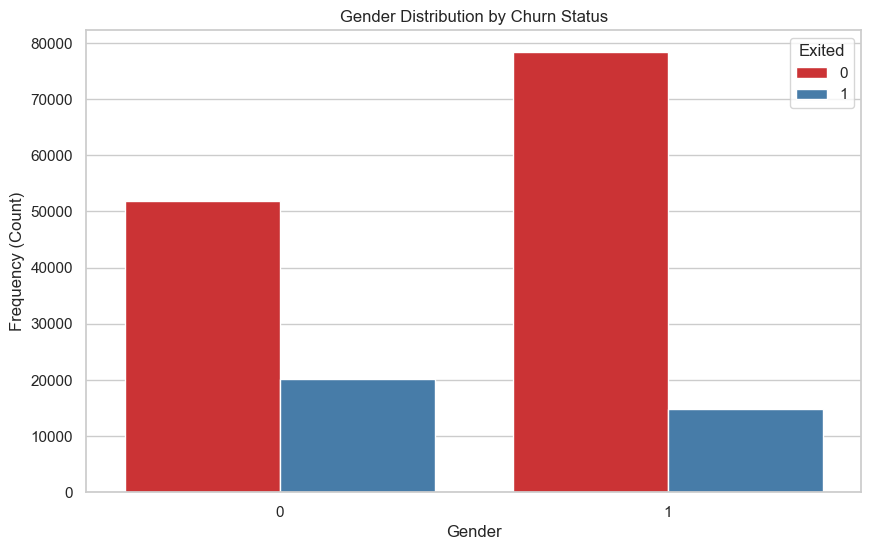

In [21]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Gender', hue='Exited', palette='Set1')
plt.title('Gender Distribution by Churn Status')
plt.xlabel('Gender')
plt.ylabel('Frequency (Count)')

plt.show()

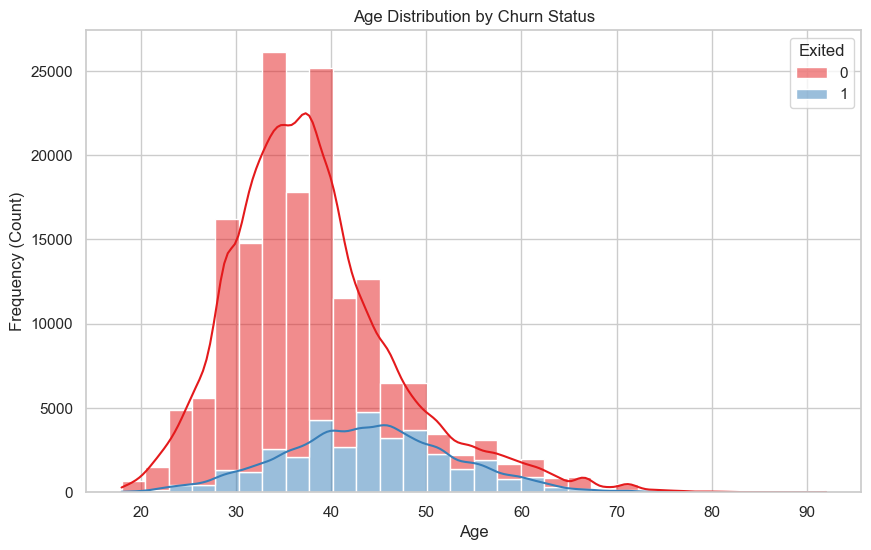

In [22]:

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Exited', bins=30, kde=True, palette='Set1', multiple='stack')
plt.title('Age Distribution by Churn Status')
plt.xlabel('Age')
plt.ylabel('Frequency (Count)')

plt.show()

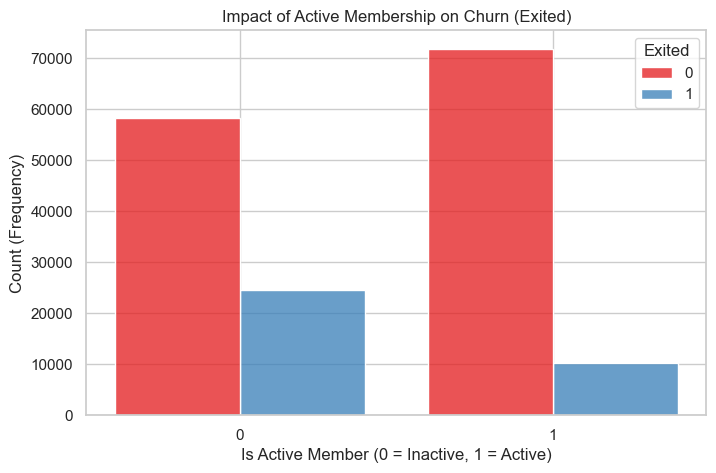

In [23]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='IsActiveMember', hue='Exited', multiple='dodge', shrink=0.8, discrete=True, palette='Set1')

plt.title('Impact of Active Membership on Churn (Exited)')
plt.xlabel('Is Active Member (0 = Inactive, 1 = Active)')
plt.ylabel('Count (Frequency)')
plt.xticks([0, 1]) 
plt.show()

In [24]:
correlation_matrix = df.corr()

<Axes: >

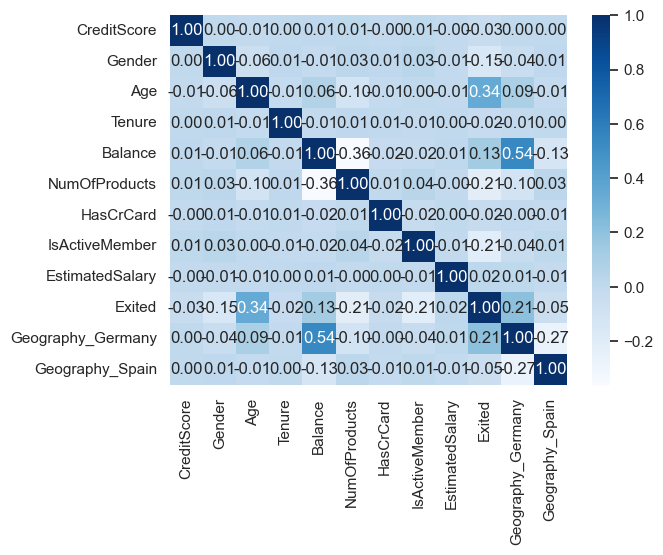

In [25]:
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f')

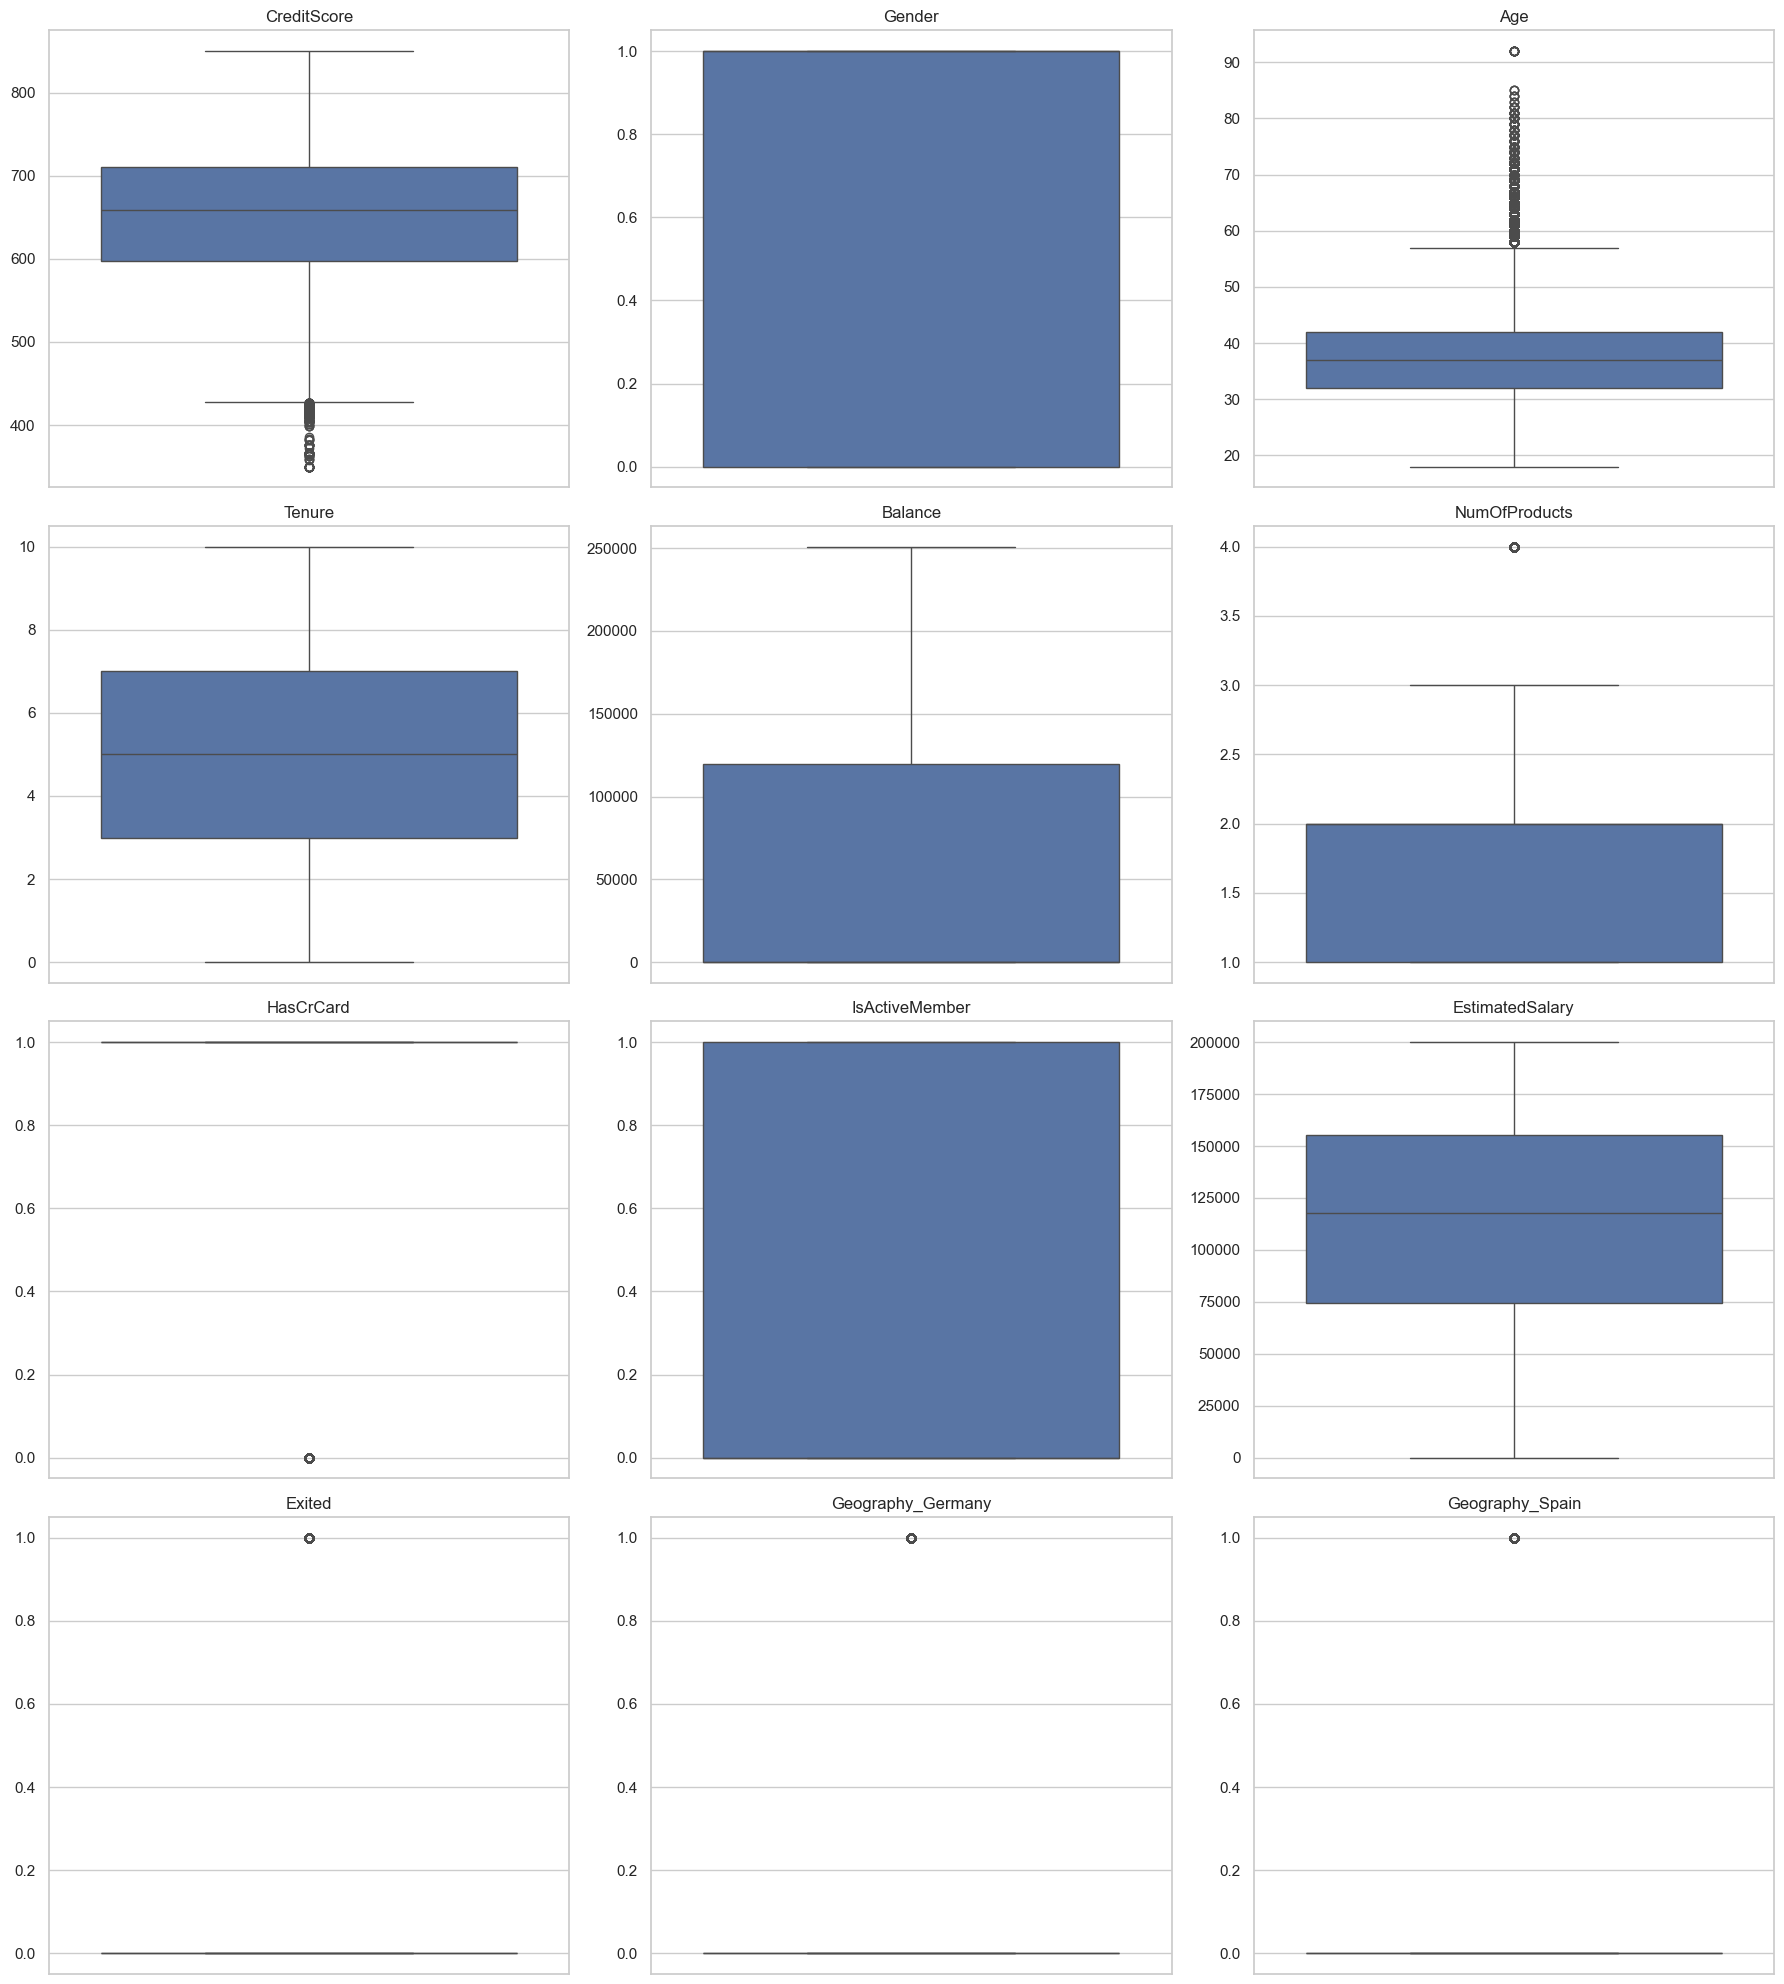

In [26]:
# Select only numerical columns
numeric_cols = df.select_dtypes(include='number').columns

# Number of columns in the grid
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

# Create the figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# Draw one boxplot for each feature
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Drop CreditScore outliers

In [27]:
Q1 = df['CreditScore'].quantile(0.25)
Q3 = df['CreditScore'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df['CreditScore'] >= lower) &
    (df['CreditScore'] <= upper)
]

In [28]:

cols_cap = [ 'Age', 'NumOfProducts']

for col in cols_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    


C:\Users\G16\AppData\Local\Temp\ipykernel_19280\663659032.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
C:\Users\G16\AppData\Local\Temp\ipykernel_19280\663659032.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
C:\Users\G16\AppData\Local\Temp\ipykernel_19280\663659032.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try u

In [29]:
for col in cols_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"The number of outliers in column {col} is now: {len(outliers)}")

The number of outliers in column Age is now: 0
The number of outliers in column NumOfProducts is now: 0


## Scaling (Normalization)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# 1. Separate features and target
X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, 

X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [31]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [32]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(
   X_train,
   y_train
)

In [33]:
# from imblearn.under_sampling import RandomUnderSampler

# rus = RandomUnderSampler(random_state=42)

# X_train, y_train = rus.fit_resample(
#     X_train,
#     y_train
# )

<Axes: xlabel='Exited', ylabel='count'>

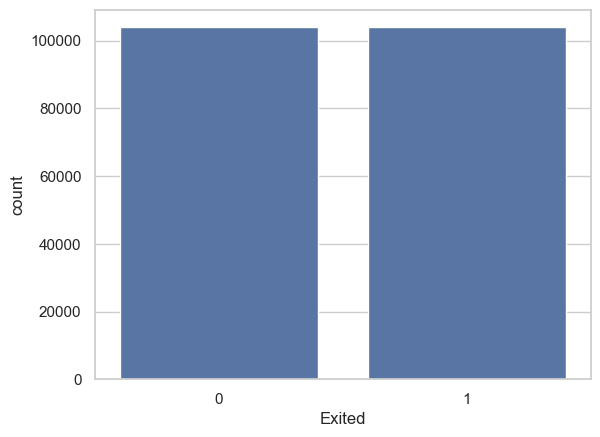

In [34]:
sns.countplot(x=y_train)

# Train models

Logistic Regression Accuracy: 0.6940558910094973

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.70      0.78     25984
           1       0.37      0.66      0.48      6973

    accuracy                           0.69     32957
   macro avg       0.63      0.68      0.63     32957
weighted avg       0.78      0.69      0.72     32957



c:\Users\G16\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


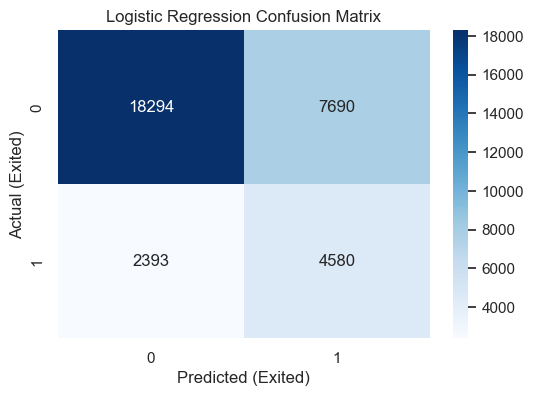

In [35]:
# تهيئة الموديل
log_reg = LogisticRegression(random_state=42)

# تدريب الموديل على البيانات بعد التقييس
log_reg.fit(X_train, y_train)

# التنبؤ ببيانات الاختبار
y_pred_log = log_reg.predict(X_test)

# طباعة التقييم
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

# رسم الـ Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('Actual (Exited)')
plt.xlabel('Predicted (Exited)')
plt.show()

In [36]:


# 1. تعريف الموديل مع موازنة الفئات
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# 2. تدريب الموديل
rf_model.fit(X_train, y_train)

# 3. التوقع على بيانات الاختبار
y_pred = rf_model.predict(X_test)

# 4. تقييم النتائج
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[24172  1812]
 [ 2930  4043]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91     25984
           1       0.69      0.58      0.63      6973

    accuracy                           0.86     32957
   macro avg       0.79      0.76      0.77     32957
weighted avg       0.85      0.86      0.85     32957



In [37]:


y_pred_probs = rf_model.predict_proba(X_test)[:, 1]

best_threshold = 0.5
best_f1 = 0

for threshold in np.arange(0.3, 0.7, 0.05):
    y_pred_custom = (y_pred_probs >= threshold).astype(int)
    current_f1 = f1_score(y_test, y_pred_custom)
    
    print(f"Threshold: {threshold:.2f} -> F1-Score: {current_f1:.4f}")
    
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = threshold

print(f"\n🌟 Best Threshold is {best_threshold:.2f} with F1-Score: {best_f1:.4f}")

y_pred_best = (y_pred_probs >= best_threshold).astype(int)
print("\nClassification Report (Best Threshold):")
print(classification_report(y_test, y_pred_best))

Threshold: 0.30 -> F1-Score: 0.6261
Threshold: 0.35 -> F1-Score: 0.6358
Threshold: 0.40 -> F1-Score: 0.6410
Threshold: 0.45 -> F1-Score: 0.6395
Threshold: 0.50 -> F1-Score: 0.6320
Threshold: 0.55 -> F1-Score: 0.6193
Threshold: 0.60 -> F1-Score: 0.5998
Threshold: 0.65 -> F1-Score: 0.5718

🌟 Best Threshold is 0.40 with F1-Score: 0.6410

Classification Report (Best Threshold):
              precision    recall  f1-score   support

           0       0.91      0.89      0.90     25984
           1       0.62      0.67      0.64      6973

    accuracy                           0.84     32957
   macro avg       0.76      0.78      0.77     32957
weighted avg       0.85      0.84      0.84     32957



In [38]:
# XGBoost model
model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

# Parameters to test
param_grid = {
    'n_estimators': [250, 200],
    'max_depth': [5, 7, 8],
    'learning_rate': [0.01, 0.04, 0.05],
    'subsample': [0.4, 0.6],
    'colsample_bytree': [0.8, 1.0]
}

# Grid Search
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train
grid.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid.best_params_)

# Best model
best_model = grid.best_estimator_

# Prediction
y_pred = best_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 250, 'subsample': 0.6}
Accuracy: 0.8624267985556938

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.91     25984
           1       0.72      0.58      0.64      6973

    accuracy                           0.86     32957
   macro avg       0.80      0.76      0.78     32957
weighted avg       0.86      0.86      0.86     32957


Confusion Matrix:
[[24398  1586]
 [ 2948  4025]]


In [39]:
from sklearn.svm import SVC

model = SVC(kernel='rbf', random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [40]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.57      0.68     25984
           1       0.27      0.58      0.37      6973

    accuracy                           0.58     32957
   macro avg       0.55      0.58      0.52     32957
weighted avg       0.72      0.58      0.62     32957

